# Multiple Biomarkers of Aging

This notebook covers the EPIC Array (bio-learn) section of the assignment. The goal is to evaluate multiple aging clocks across two complete EPIC array datasets and compare their performance through correlation matrices, heatmaps, and age prediction plots.

We use the Biolearn library, an open-source Python framework developed by the Biomarkers of Aging Consortium. It provides standardized implementations of aging clocks and loads publicly available methylation datasets directly from GEO (Gene Expression Omnibus) without any manual downloading or preprocessing.

Paper reference: Ying et al. (2023). Biolearn, an open-source library for biomarkers of aging. bioRxiv. https://doi.org/10.1101/2023.12.02.569722

In [1]:
!pip install biolearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 11.5 MB/s eta 0:00:00


## Imports

We import the three core biolearn functions we need for this assignment. DataLibrary handles loading GEO datasets. ModelGallery gives us access to all the aging clock implementations. The three visualize functions directly produce the three plots the assignment asks for.

In [2]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from biolearn.data_library import DataLibrary
from biolearn.model_gallery import ModelGallery
from biolearn.visualize import (
    plot_clock_correlation_matrix,
    plot_clock_deviation_heatmap,
    plot_age_prediction
)

print("All imports successful.")

All imports successful.


## Dataset Selection

We selected two blood DNA methylation datasets from the Biolearn data library, both measured on Illumina 450k/EPIC arrays and both containing chronological age metadata for all samples.

**Dataset 1: GSE120307**
A blood methylation dataset spanning a broad age range. This is the dataset used in the official Biolearn documentation examples, making it a well validated choice. It was profiled using the Illumina 450k array platform.

**Dataset 2: GSE41169**
A blood DNA methylation dataset with 95 samples measured on the Illumina 450k array, from a Dutch population study. It has a good age range with both age and sex metadata present, making it fully compatible with all the aging clocks we are using.

In [3]:
print("Loading Dataset 1: GSE120307 ...")
data1 = DataLibrary().get("GSE120307").load()
print(f"Samples: {data1.metadata.shape[0]}, CpG sites: {data1.dnam.shape[0]}")
print(f"Age range: {data1.metadata['age'].min():.1f} to {data1.metadata['age'].max():.1f} years")
print()
print("Loading Dataset 2: GSE41169 ...")
data2 = DataLibrary().get("GSE41169").load()
print(f"Samples: {data2.metadata.shape[0]}, CpG sites: {data2.dnam.shape[0]}")
print(f"Age range: {data2.metadata['age'].min():.1f} to {data2.metadata['age'].max():.1f} years")

Loading Dataset 1: GSE120307 ...
Samples: 34, CpG sites: 485512
Age range: 19.0 to 54.0 years

Loading Dataset 2: GSE41169 ...
Samples: 95, CpG sites: 485577
Age range: 18.0 to 65.0 years


## Aging Clock Selection

An epigenetic aging clock is a mathematical model that predicts biological or chronological age from DNA methylation patterns at specific CpG sites. Different clocks were trained on different datasets, tissues, and to predict different outcomes.

We selected 8 clocks that span three generations of clock development:

**Horvathv1 (2013)** — The original pan-tissue clock trained on 353 CpGs across 51 tissue types. The most cited aging clock in the field and the baseline everyone compares against.

**Hannum (2013)** — Blood specific clock using 71 CpGs from Illumina 450k data. Developed at the same time as Horvath but designed exclusively for blood.

**PhenoAge (2018)** — A second generation clock trained to predict phenotypic age using clinical biomarkers as an intermediate. Has stronger association with mortality and disease than first generation clocks.

**DunedinPACE (2022)** — Does not predict age in years. Instead it predicts the pace of aging as a rate (e.g. 0.9 means aging 10% slower than average). This is a fundamentally different concept from the other clocks.

**Lin (2016)** — A blood specific clock using 99 CpGs. Designed specifically to work well on blood tissue.

**Zhang_10 (2019)** — A mortality associated clock using only 10 CpGs. Demonstrates how much predictive power is possible with a minimal marker set.

**YingCausAge (2022)** — A causality enriched clock. Rather than selecting CpGs that merely correlate with age, it targets CpGs with causal links to aging.

**YingDamAge (2022)** — Also causality enriched, but specifically targets methylation changes associated with biological damage accumulation during aging.

In [4]:
clock_names = [
    "Horvathv1",
    "Hannum",
    "PhenoAge",
    "DunedinPACE",
    "Lin",
    "Zhang_10",
    "YingCausAge",
    "YingDamAge",
]

gallery = ModelGallery()
models = [gallery.get(name) for name in clock_names]
print(f"Loaded {len(models)} aging clocks successfully.")

Loaded 8 aging clocks successfully.


## Correlation Matrix Across Aging Clocks

The correlation matrix shows how strongly each pair of clocks agree with each other across all samples. A high correlation (close to 1.0) between two clocks means they tend to rank samples similarly by predicted age. A low correlation means they are capturing different biological signals.

First generation chronological clocks like Horvathv1 and Hannum are expected to correlate more strongly with each other. DunedinPACE is expected to show lower correlations since it measures pace of aging rather than absolute age in years. We produce this separately for both datasets to see if the inter-clock relationships are consistent across cohorts.

Dataset 1: GSE120307


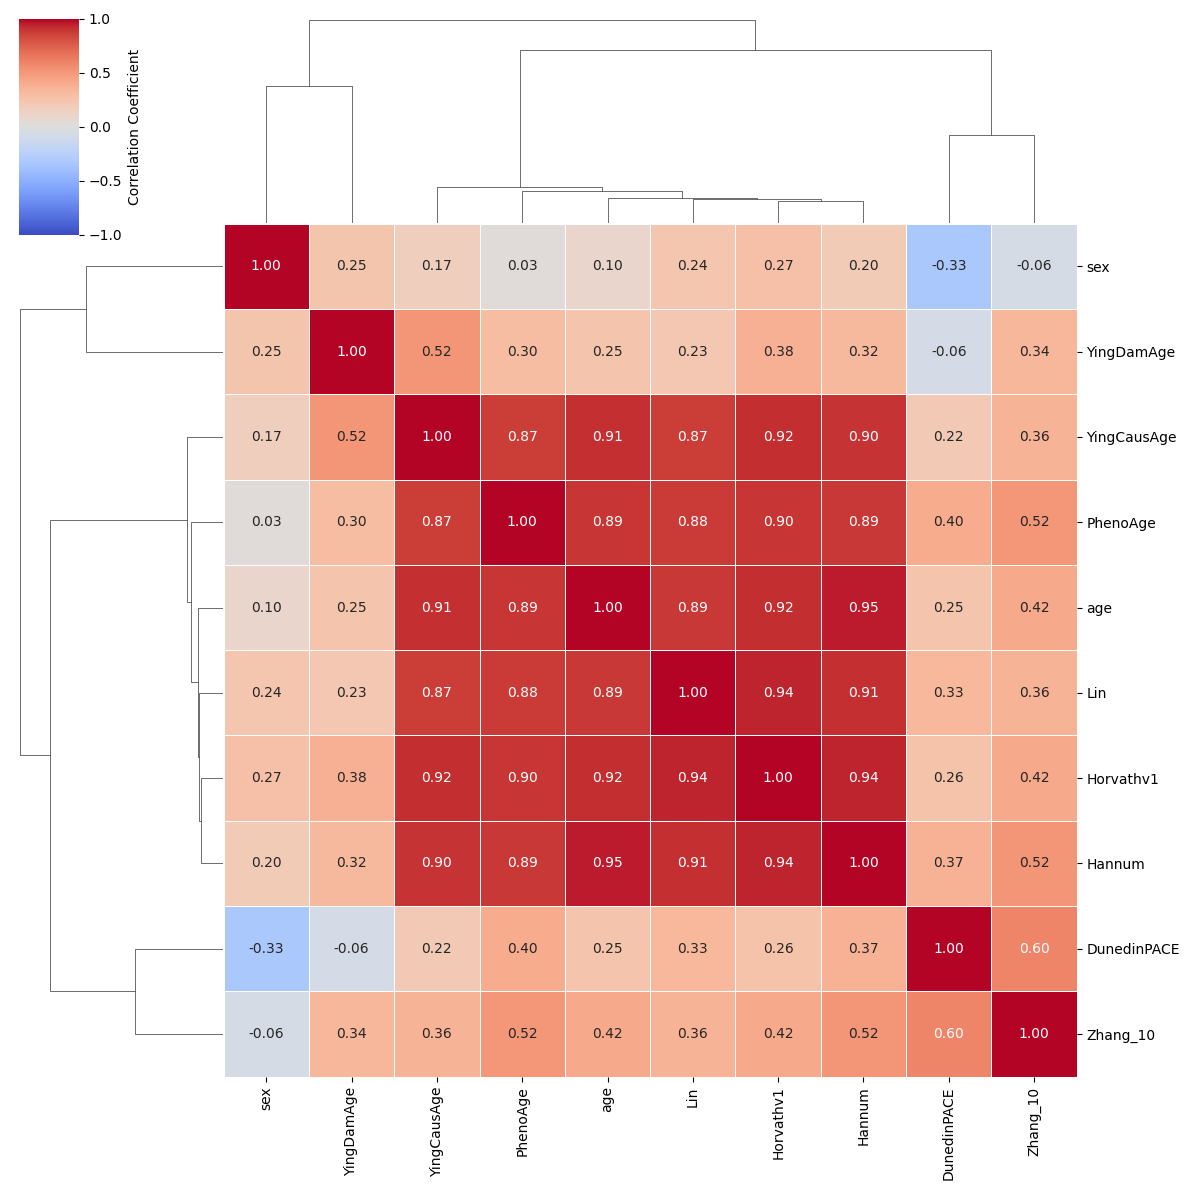

<Figure size 640x480 with 0 Axes>

In [5]:
print("Dataset 1: GSE120307")
plot_clock_correlation_matrix(models=models, data=data1)
plt.suptitle("Clock Correlation Matrix — GSE120307", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Dataset 2: GSE41169


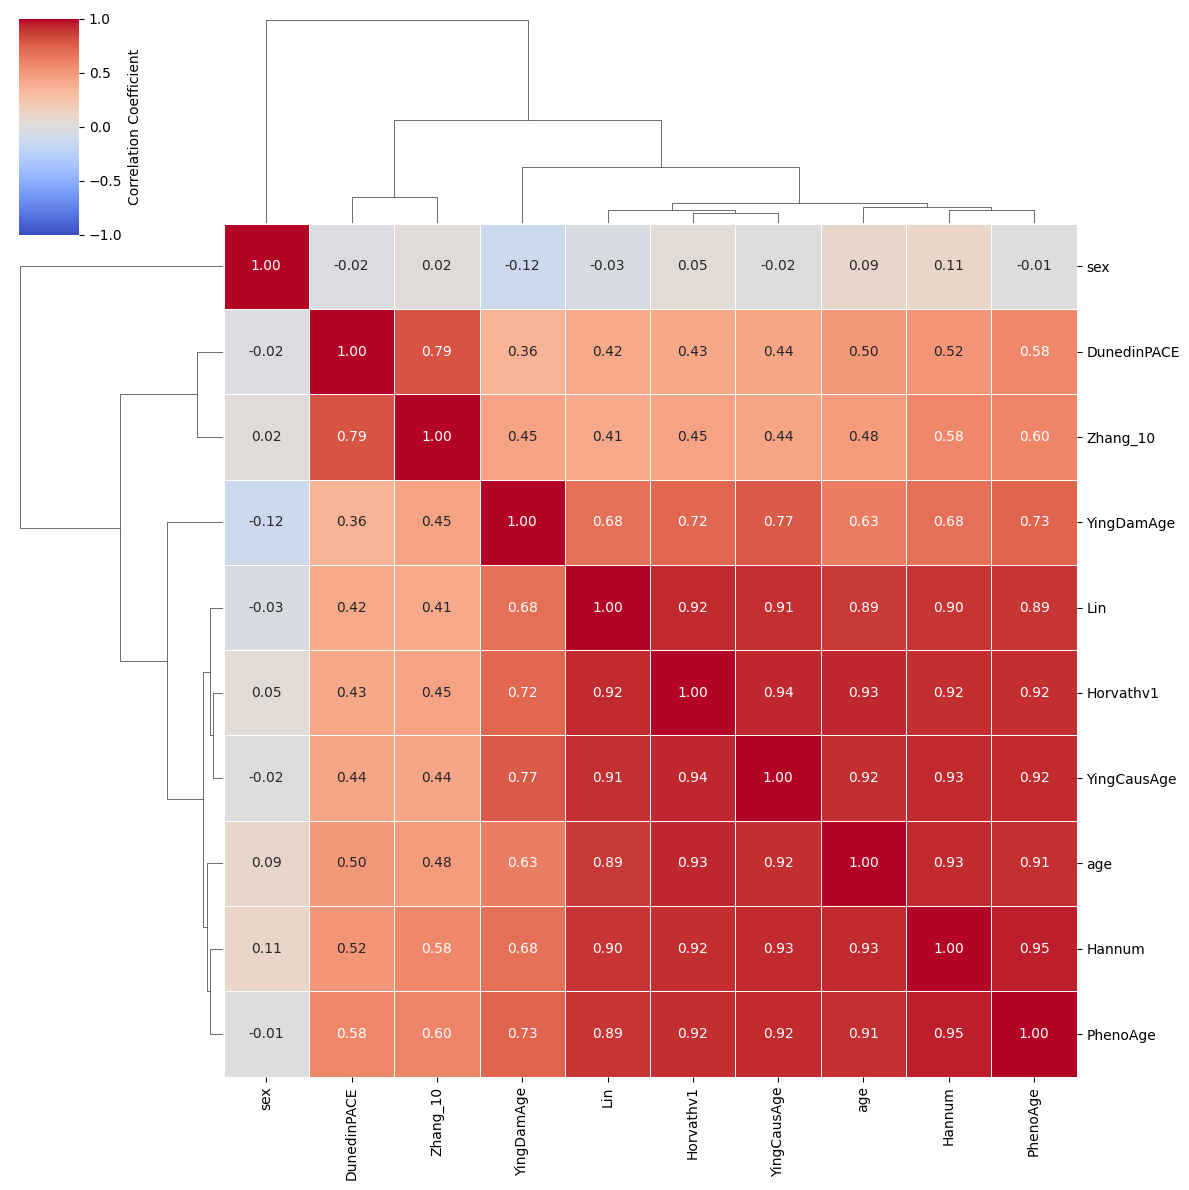

<Figure size 640x480 with 0 Axes>

In [6]:
print("Dataset 2: GSE41169")
plot_clock_correlation_matrix(models=models, data=data2)
plt.suptitle("Clock Correlation Matrix — GSE41169", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Clock Predictions vs Chronological Age

These scatter plots show each clock's predicted age on the y-axis against the sample's true chronological age on the x-axis. Each dot is one sample. A perfect clock would place all dots exactly on the diagonal line where predicted age equals actual age.

DunedinPACE is excluded from this plot because it does not output age in years. Plotting a dimensionless pace-of-aging rate on the same y-axis as years would produce a meaningless comparison.

Clocks with tighter scatter around the diagonal have higher accuracy. Some clocks show compression at the extremes, predicting too high for young samples and too low for old samples. This is called regression to the mean and is a known limitation of many linear epigenetic clocks trained on datasets with limited representation at age extremes.

Dataset 1: GSE120307


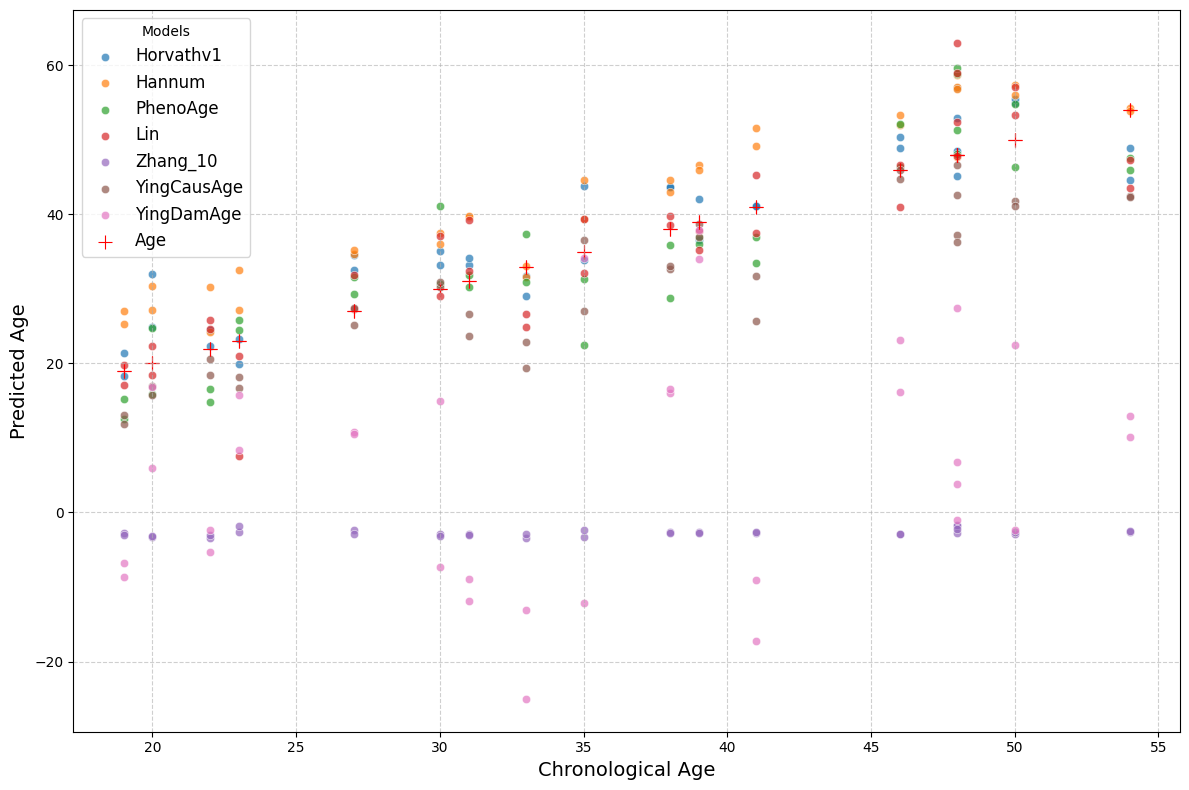

<Figure size 640x480 with 0 Axes>

In [7]:
age_clock_names = ["Horvathv1", "Hannum", "PhenoAge", "Lin", "Zhang_10", "YingCausAge", "YingDamAge"]
age_models = [gallery.get(name) for name in age_clock_names]

print("Dataset 1: GSE120307")
plot_age_prediction(models=age_models, data=data1)
plt.suptitle("Age Prediction vs Chronological Age — GSE120307", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Dataset 2: GSE41169


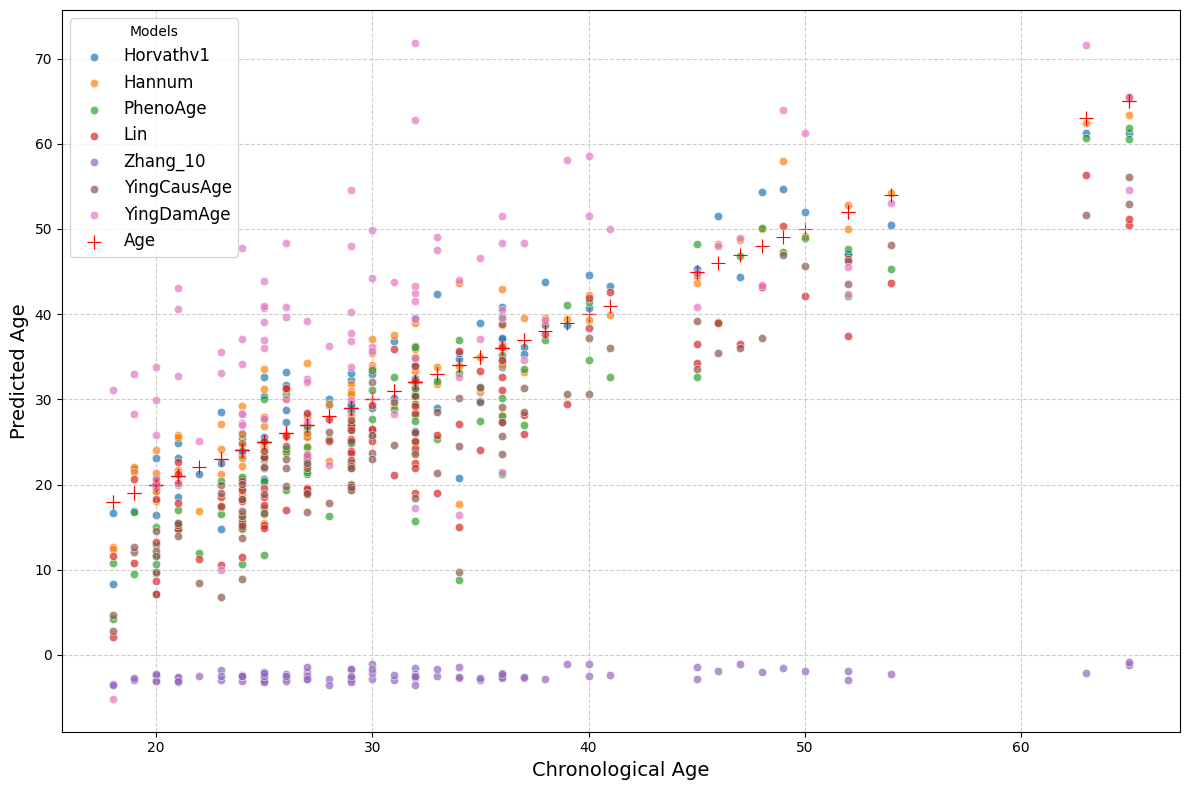

<Figure size 640x480 with 0 Axes>

In [8]:
print("Dataset 2: GSE41169")
plot_age_prediction(models=age_models, data=data2)
plt.suptitle("Age Prediction vs Chronological Age — GSE41169", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Age Deviation Heatmap

This heatmap shows for each sample (rows) and each clock (columns) how much the clock's predicted age deviates from the sample's actual chronological age. The deviation is simply predicted age minus chronological age. Warm colors (positive) mean the clock thinks the sample is biologically older than their real age. Cool colors (negative) mean the clock thinks the sample is biologically younger. This lets us spot both systematic clock biases and individual samples that are consistently flagged as accelerated or decelerated agers across multiple clocks.

Dataset 1: GSE120307


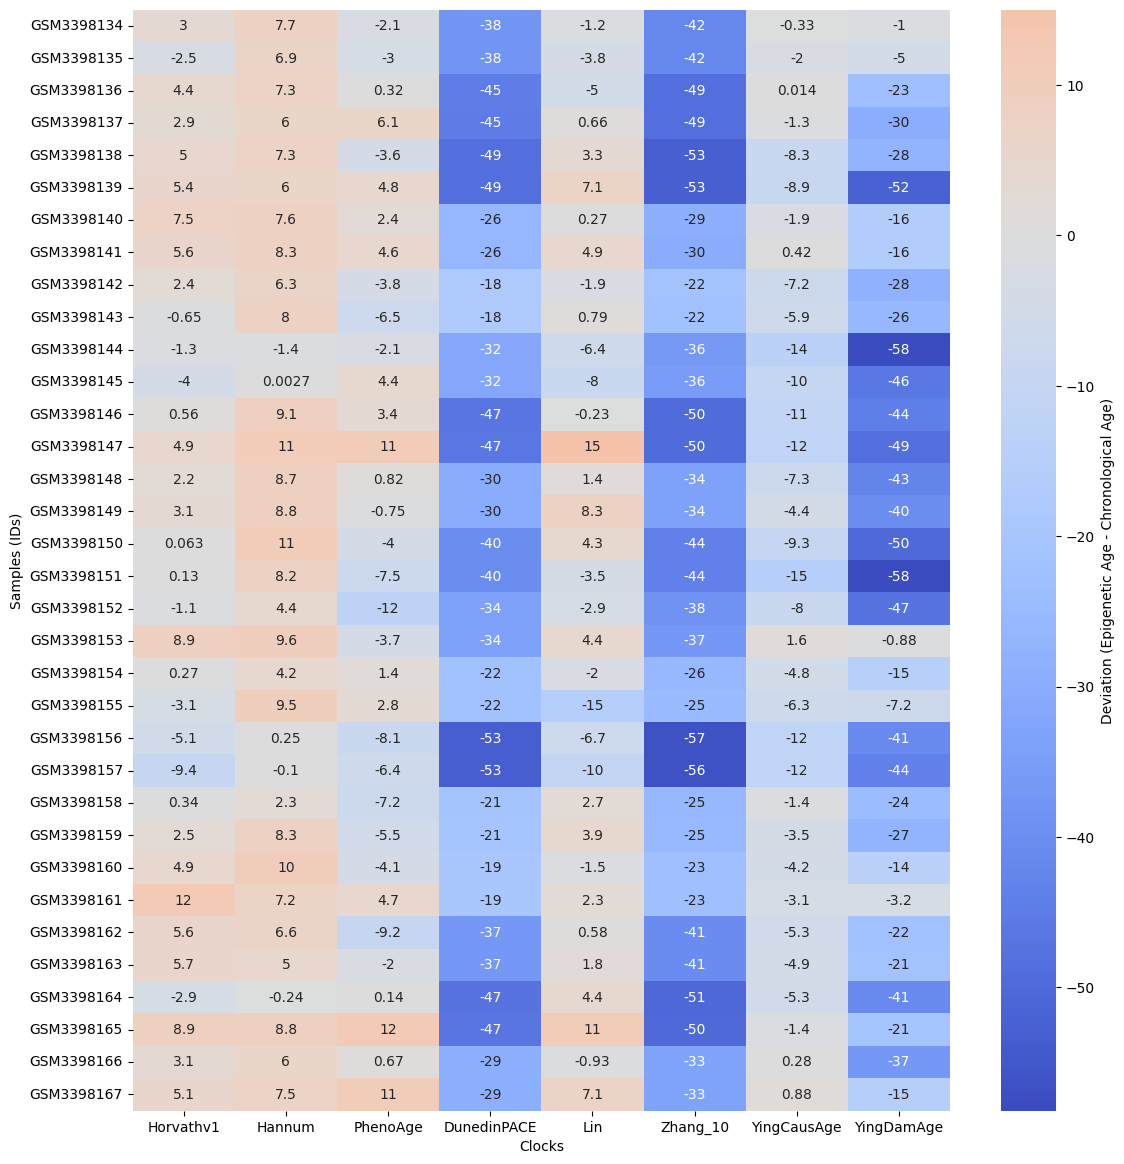

<Figure size 640x480 with 0 Axes>

In [9]:
print("Dataset 1: GSE120307")
plot_clock_deviation_heatmap(models=models, data=data1)
plt.suptitle("Age Deviation Heatmap — GSE120307", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Dataset 2: GSE41169


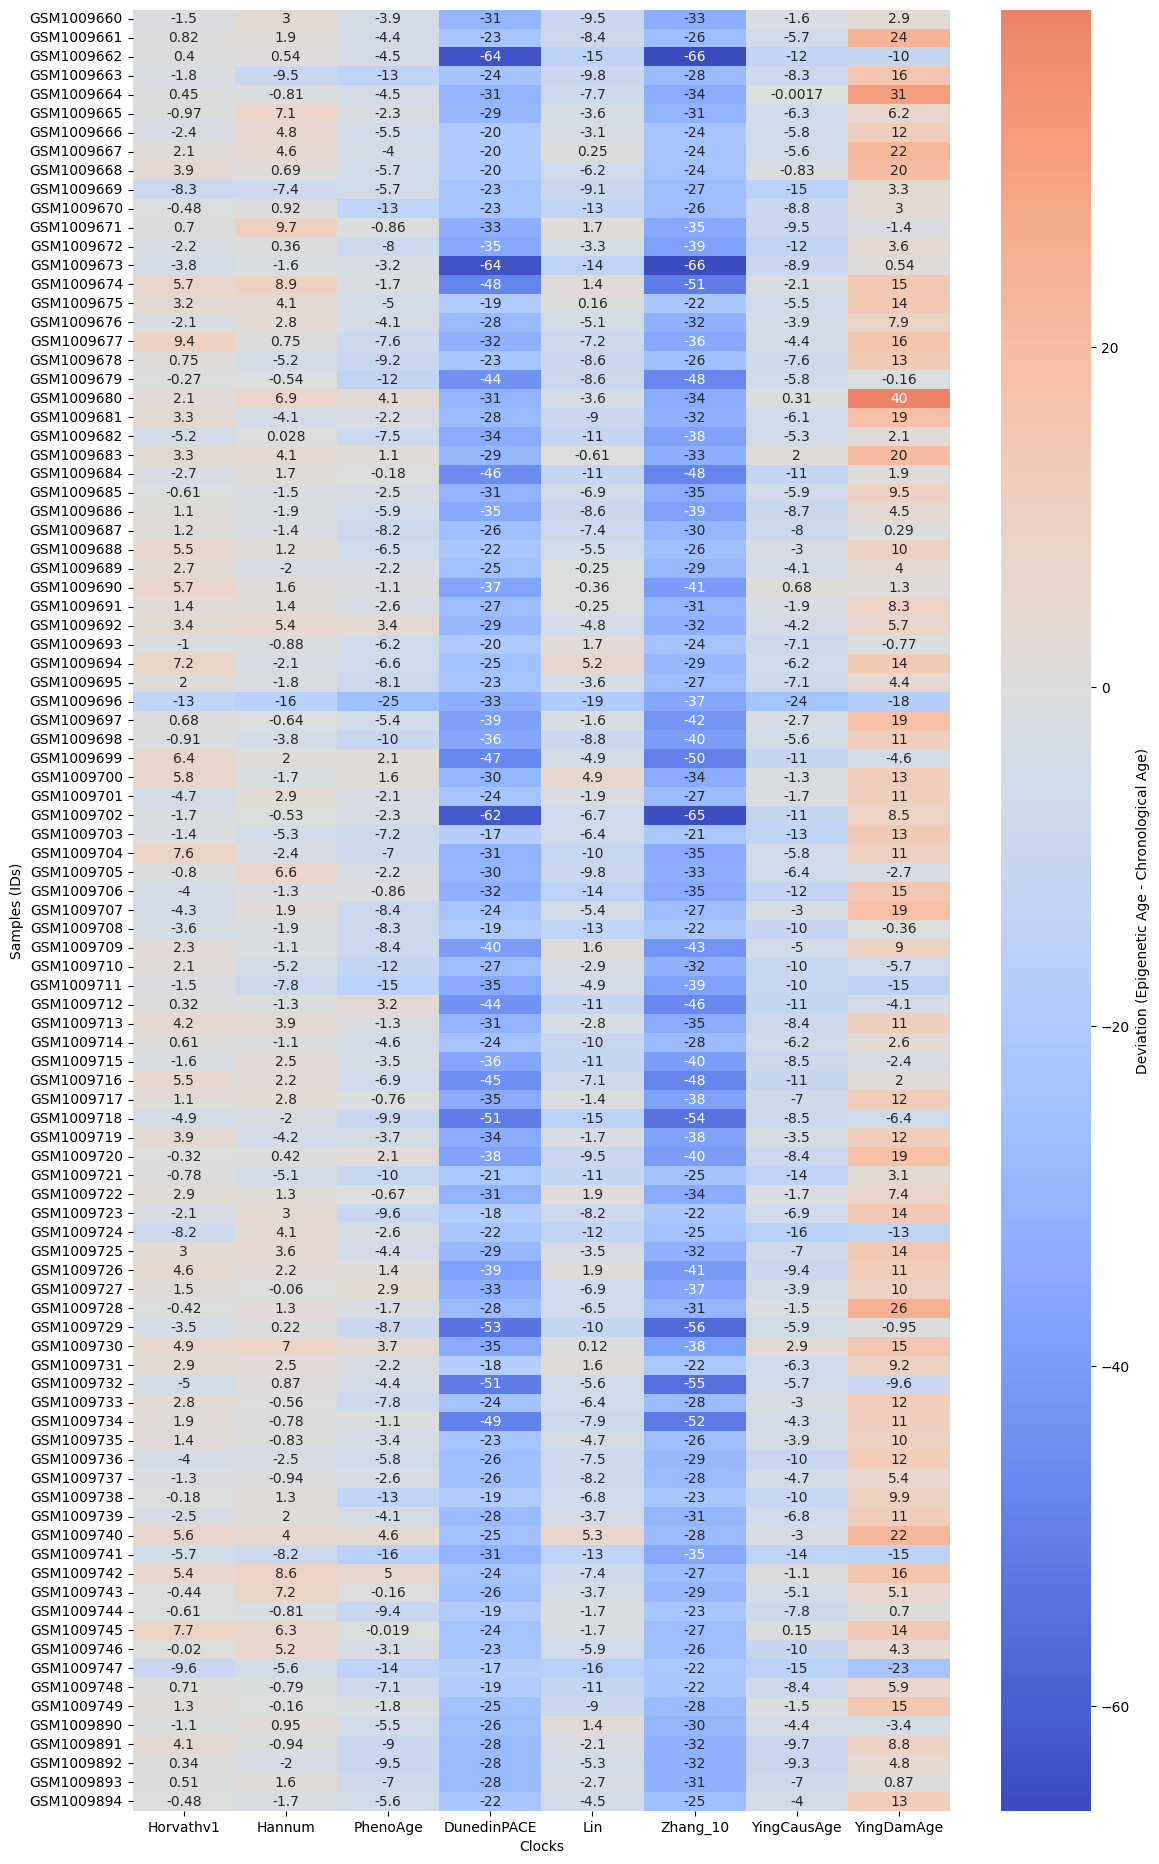

<Figure size 640x480 with 0 Axes>

In [10]:
print("Dataset 2: GSE41169")
plot_clock_deviation_heatmap(models=models, data=data2)
plt.suptitle("Age Deviation Heatmap — GSE41169", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Comparing Mean Absolute Error Across Clocks

To quantitatively benchmark how accurate each clock is at predicting chronological age, we compute the Mean Absolute Error (MAE) for each clock on both datasets. MAE tells us on average how many years off a clock's prediction is from the true age. Lower MAE means better accuracy. This lets us directly compare clock performance across the two datasets.

             GSE120307  GSE41169
Horvathv1         3.96      2.95
Hannum            6.45      3.05
PhenoAge          4.77      5.57
Lin               4.53      6.36
Zhang_10         38.27     33.99
YingCausAge       5.68      6.76
YingDamAge       29.24     10.21


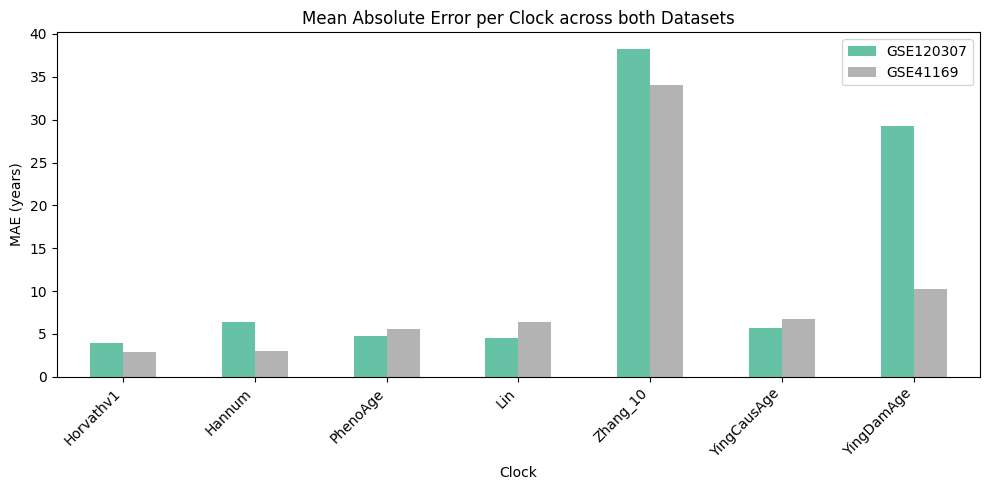

In [12]:
import pandas as pd
import numpy as np

mae_results = {}
for name, model in zip(age_clock_names, age_models):
    try:
        result1 = model.predict(data1)
        result2 = model.predict(data2)

        # biolearn returns a dataframe directly
        pred1 = result1.iloc[:, 0]
        pred2 = result2.iloc[:, 0]

        actual1 = data1.metadata['age']
        actual2 = data2.metadata['age']

        common1 = pred1.index.intersection(actual1.index)
        common2 = pred2.index.intersection(actual2.index)

        mae1 = np.mean(np.abs(pred1[common1] - actual1[common1]))
        mae2 = np.mean(np.abs(pred2[common2] - actual2[common2]))

        mae_results[name] = {'GSE120307': round(mae1, 2), 'GSE41169': round(mae2, 2)}
    except Exception as e:
        print(f"Skipping {name}: {e}")

mae_df = pd.DataFrame(mae_results).T
print(mae_df)

mae_df.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title("Mean Absolute Error per Clock across both Datasets")
plt.ylabel("MAE (years)")
plt.xlabel("Clock")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Distribution of Predicted Ages per Clock

These box plots show the distribution of predicted ages from each clock across all samples in each dataset. This helps us see whether a clock has a wide or narrow prediction range, and whether it is well calibrated to the actual age distribution of the dataset. A clock whose box plot is roughly centered on the actual age range of the dataset is better calibrated than one that consistently predicts too high or too low.

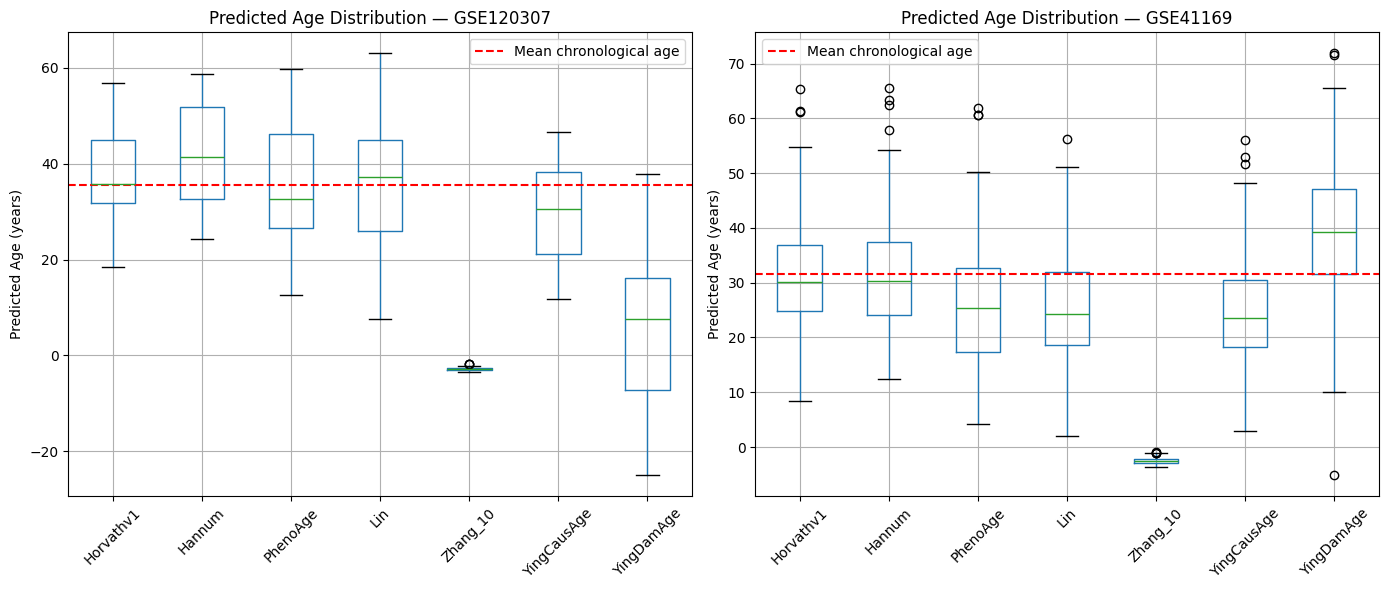

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in zip(axes, [data1, data2], ["GSE120307", "GSE41169"]):
    preds = {}
    for name, model in zip(age_clock_names, age_models):
        try:
            result = model.predict(data)
            preds[name] = result.iloc[:, 0].values
        except Exception as e:
            print(f"Skipping {name}: {e}")
    pred_df = pd.DataFrame(preds)
    pred_df.boxplot(ax=ax, rot=45)
    ax.axhline(y=data.metadata['age'].mean(), color='red', linestyle='--', label='Mean chronological age')
    ax.set_title(f"Predicted Age Distribution — {title}")
    ax.set_ylabel("Predicted Age (years)")
    ax.legend()

plt.tight_layout()
plt.show()